In [10]:
import pandas as pd

# Load the required CSV files (ensure files are uploaded to your Colab environment)
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [11]:
# Check missing values in orders
print("Missing values in Orders:\n", orders.isnull().sum())

# Check for duplicate rows across datasets
print("Duplicate rows in orders:", orders.duplicated().sum())
print("Duplicate rows in order_items:", order_items.duplicated().sum())

Missing values in Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicate rows in orders: 0
Duplicate rows in order_items: 0


In [12]:
import pandas as pd

# 1. LOAD DATASETS (Ensure files are uploaded in Colab)
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# 2. CLEAN DATA
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders = orders.drop_duplicates().dropna(subset=['order_id', 'customer_id', 'order_purchase_timestamp'])
order_items = order_items.drop_duplicates().dropna(subset=['order_id', 'product_id', 'price'])

# 3. MERGE TABLES
df_merged = pd.merge(orders, order_items, on='order_id', how='inner')
df_merged = pd.merge(df_merged, products, on='product_id', how='inner')
df_merged = pd.merge(df_merged, customers, on='customer_id', how='inner')
df_merged = pd.merge(df_merged, reviews[['order_id', 'review_score']], on='order_id', how='left')

print("Data cleaning & merging complete! Final shape:", df_merged.shape, "\n")

# ==========================================
# 4. SALES ANALYSIS (5 QUESTIONS)
# ==========================================

# Q1: Product category with highest revenue
top_categories = df_merged.groupby('product_category_name')['price'].sum().reset_index()
top_categories = top_categories.sort_values(by='price', ascending=False)
print("--- 1. Top Product Category by Revenue ---")
print(top_categories.head(1), "\n")

# Q2: Month with peak sales
df_merged['order_month'] = df_merged['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df_merged.groupby('order_month')['price'].sum().reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)
peak_month = monthly_sales.loc[monthly_sales['price'].idxmax()]
print("--- 2. Month with Peak Sales ---")
print(peak_month, "\n")

# Q3: Best performing region (Customer State)
regional_sales = df_merged.groupby('customer_state')['price'].sum().reset_index()
regional_sales = regional_sales.sort_values(by='price', ascending=False)
print("--- 3. Best Performing Region (State) ---")
print(regional_sales.head(1), "\n")

# Q4: Average Order Value (AOV) trend
order_totals = df_merged.groupby('order_id')['price'].sum().reset_index()
order_totals['order_month'] = df_merged['order_purchase_timestamp'].dt.to_period('M')
aov_trend = order_totals.groupby('order_month')['price'].mean().reset_index()
aov_trend['order_month'] = aov_trend['order_month'].astype(str)
print("--- 4. Average Order Value (AOV) Trend (First 5 Months) ---")
print(aov_trend.head(), "\n")

# Q5: Customer review score distribution
if 'review_score' in df_merged.columns:
    review_dist = df_merged['review_score'].value_counts().sort_index()
    print("--- 5. Customer Review Score Distribution ---")
    print(review_dist)


Data cleaning & merging complete! Final shape: (113314, 27) 

--- 1. Top Product Category by Revenue ---
   product_category_name       price
11          beleza_saude  1263138.54 

--- 2. Month with Peak Sales ---
order_month       2017-11
price          1017758.83
Name: 13, dtype: object 

--- 3. Best Performing Region (State) ---
   customer_state       price
25             SP  5228869.17 

--- 4. Average Order Value (AOV) Trend (First 5 Months) ---
  order_month       price
0     2016-09   80.761667
1     2016-10  129.321270
2     2016-12  138.000000
3     2017-01  150.082719
4     2017-02  147.546429 

--- 5. Customer Review Score Distribution ---
review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64


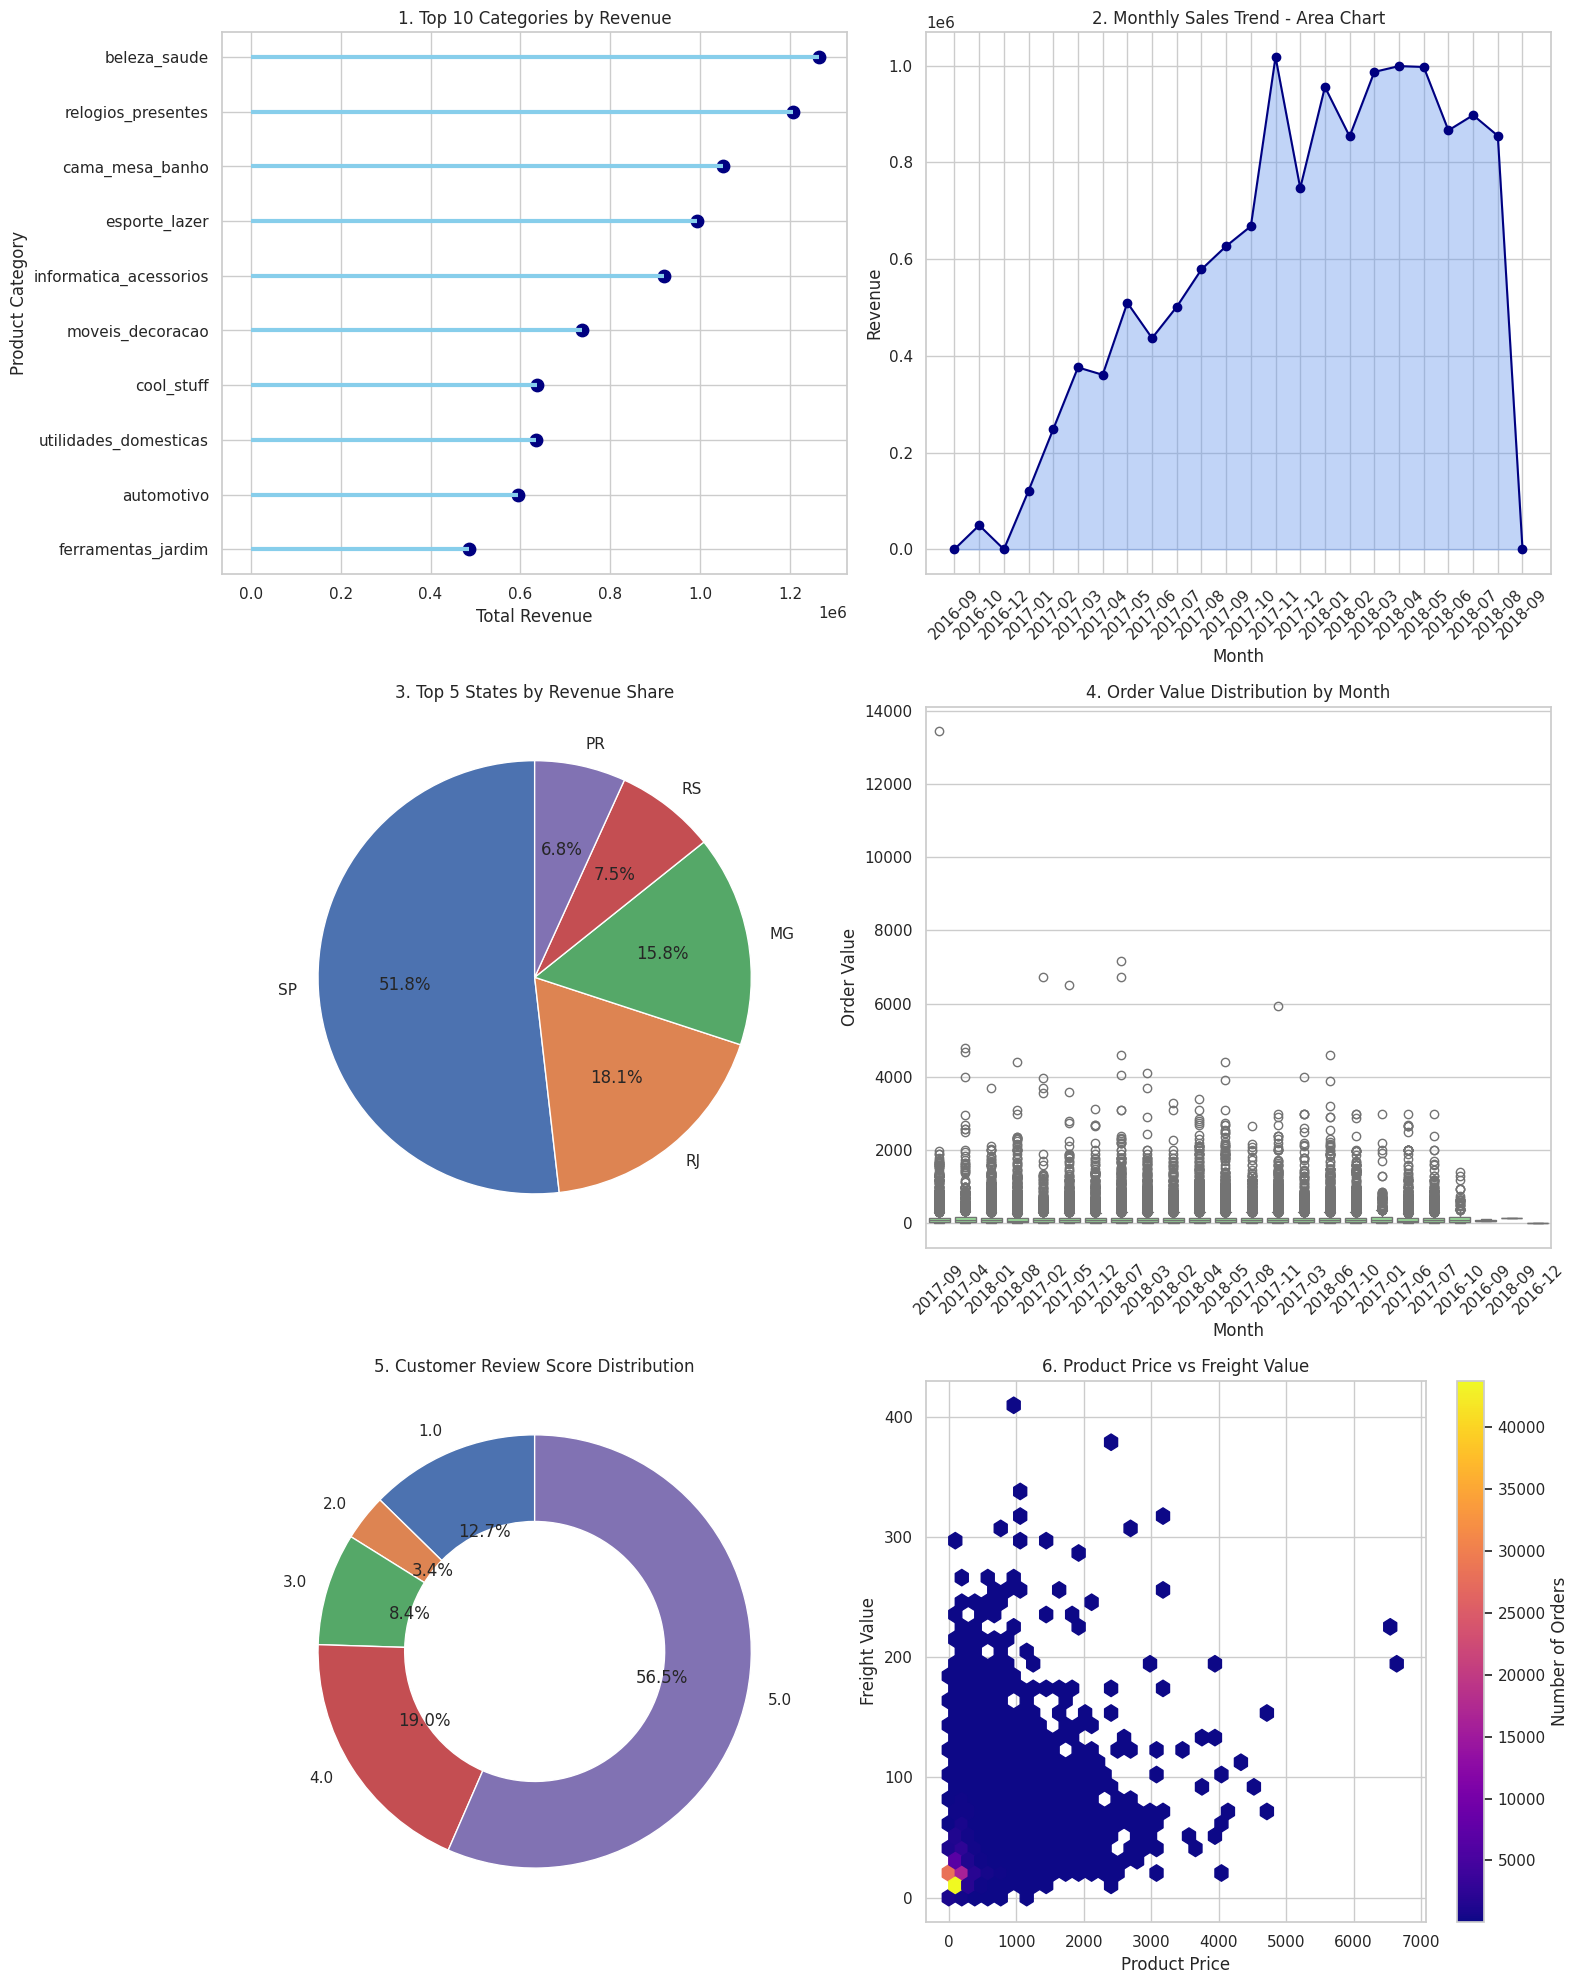

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Top 10 Product Categories by Revenue
# Horizontal Bar Chart -> Lollipop Chart
top_10_cat = (
    df_merged.groupby('product_category_name')['price']
    .sum()
    .nlargest(10)
    .sort_values()
)

axes[0, 0].hlines(
    y=top_10_cat.index,
    xmin=0,
    xmax=top_10_cat.values,
    color='skyblue',
    linewidth=3
)

axes[0, 0].scatter(
    top_10_cat.values,
    top_10_cat.index,
    color='navy',
    s=80
)

axes[0, 0].set_title('1. Top 10 Categories by Revenue')
axes[0, 0].set_xlabel('Total Revenue')
axes[0, 0].set_ylabel('Product Category')


# 2. Monthly Sales Trend
# Line Chart -> Area Chart
monthly_trend = (
    df_merged.groupby('order_month')['price']
    .sum()
    .reset_index()
)

monthly_trend = monthly_trend.sort_values('order_month')
monthly_trend['order_month'] = monthly_trend['order_month'].astype(str)

axes[0, 1].fill_between(
    range(len(monthly_trend)),
    monthly_trend['price'],
    alpha=0.4,
    color='cornflowerblue'
)

axes[0, 1].plot(
    range(len(monthly_trend)),
    monthly_trend['price'],
    marker='o',
    color='navy'
)

axes[0, 1].set_xticks(range(len(monthly_trend)))
axes[0, 1].set_xticklabels(
    monthly_trend['order_month'],
    rotation=45
)

axes[0, 1].set_title('2. Monthly Sales Trend - Area Chart')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue')


# 3. Top 5 States by Revenue
# Bar Chart -> Pie Chart
top_states = (
    df_merged.groupby('customer_state')['price']
    .sum()
    .nlargest(5)
)

axes[1, 0].pie(
    top_states.values,
    labels=top_states.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

axes[1, 0].set_title('3. Top 5 States by Revenue Share')


# 4. Average Order Value by Month
# Bar Chart -> Box Plot
order_totals = (
    df_merged.groupby(['order_id', 'order_month'])['price']
    .sum()
    .reset_index()
)

sns.boxplot(
    data=order_totals,
    x='order_month',
    y='price',
    ax=axes[1, 1],
    color='lightgreen'
)

axes[1, 1].set_title('4. Order Value Distribution by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Order Value')
axes[1, 1].tick_params(axis='x', rotation=45)


# 5. Customer Review Score Distribution
# Count Plot -> Donut Chart
if 'review_score' in df_merged.columns:

    review_counts = df_merged['review_score'].value_counts().sort_index()

    axes[2, 0].pie(
        review_counts.values,
        labels=review_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4, 'edgecolor': 'white'}
    )

    axes[2, 0].set_title('5. Customer Review Score Distribution')


# 6. Product Price vs Freight Value
# Scatter Plot -> Hexbin Plot
hex_plot = axes[2, 1].hexbin(
    df_merged['price'],
    df_merged['freight_value'],
    gridsize=35,
    cmap='plasma',
    mincnt=1
)

axes[2, 1].set_title('6. Product Price vs Freight Value')
axes[2, 1].set_xlabel('Product Price')
axes[2, 1].set_ylabel('Freight Value')

fig.colorbar(
    hex_plot,
    ax=axes[2, 1],
    label='Number of Orders'
)

plt.tight_layout()
plt.show()